## 1. Import thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models

## 2. Load & tiền xử lý dữ liệu MNIST

In [2]:
print("Đang tải dữ liệu MNIST...")
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)

print("Kích thước dữ liệu:", X.shape, y.shape)

# Chuẩn hóa pixel về [0,1]
X = X / 255.0

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Đang tải dữ liệu MNIST...
Kích thước dữ liệu: (70000, 784) (70000,)


## PHẦN 1: Machine Learning cơ bản

In [3]:
print("\n--- Logistic Regression ---")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree ---")
dt = DecisionTreeClassifier(max_depth=20)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("\n--- KNN ---")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


--- Logistic Regression ---
Accuracy: 0.9199285714285714
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000


--- Decision Tree ---
Accuracy: 0.8740714285714286
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1343
           1       0.9

## PHẦN 2: Deep Learning - CNN trên MNIST

In [4]:
# Reshape dữ liệu về dạng ảnh 28x28x1
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history_cnn = cnn.fit(X_train_cnn, y_train,
                      validation_data=(X_test_cnn, y_test),
                      epochs=5, batch_size=128, verbose=2)

c:\Users\NGUYEN THU\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
438/438 - 5s - 11ms/step - accuracy: 0.9340 - loss: 0.2190 - val_accuracy: 0.9704 - val_loss: 0.0988
Epoch 2/5
438/438 - 4s - 9ms/step - accuracy: 0.9823 - loss: 0.0574 - val_accuracy: 0.9844 - val_loss: 0.0479
Epoch 3/5
438/438 - 4s - 9ms/step - accuracy: 0.9882 - loss: 0.0389 - val_accuracy: 0.9864 - val_loss: 0.0423
Epoch 4/5
438/438 - 4s - 9ms/step - accuracy: 0.9910 - loss: 0.0300 - val_accuracy: 0.9886 - val_loss: 0.0344
Epoch 5/5
438/438 - 4s - 9ms/step - accuracy: 0.9927 - loss: 0.0236 - val_accuracy: 0.9884 - val_loss: 0.0364



Độ chính xác CNN trên tập test: 0.9884


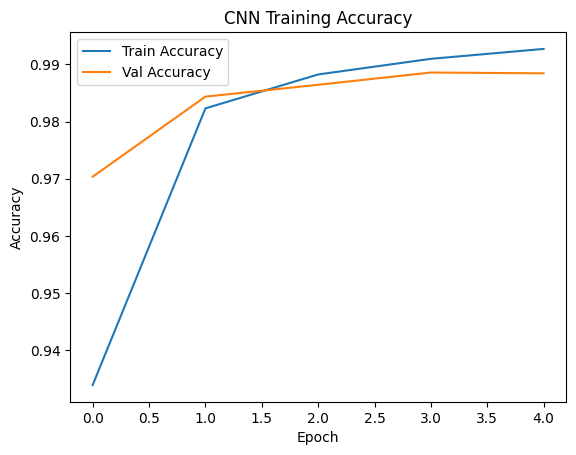

In [5]:
# Đánh giá CNN
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nĐộ chính xác CNN trên tập test: {test_acc:.4f}")

# Vẽ biểu đồ accuracy
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("CNN Training Accuracy")
plt.show()

## PHẦN 3: So sánh hiệu suất


So sánh độ chính xác:
Logistic Regression: 0.9199
Decision Tree: 0.8741
KNN (k=3): 0.9713
CNN: 0.9884


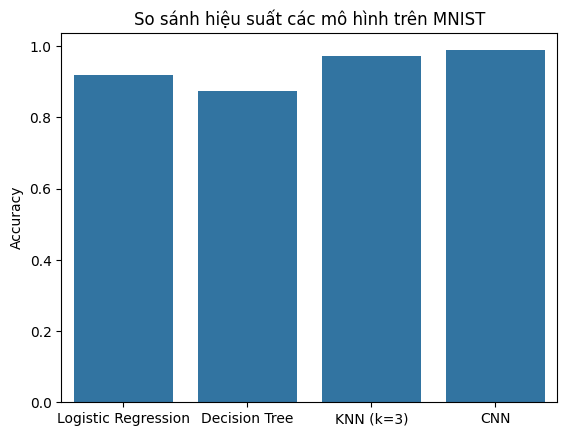

In [6]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "KNN (k=3)": accuracy_score(y_test, y_pred_knn),
    "CNN": test_acc
}

print("\nSo sánh độ chính xác:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Accuracy")
plt.title("So sánh hiệu suất các mô hình trên MNIST")
plt.show()